In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import (
    plot_bloch_multivector,
    plot_state_city,
    plot_histogram
)
from qiskit_aer import AerSimulator

import matplotlib.pyplot as plt
import numpy as np

# Exercise 1 Easy

## Implementing Pauli-X, Pauli-Y and Pauli-Z Gates

### Pauli-X Gate

The Pauli-X gate flips the qubit from |0⟩ to |1⟩.
### Matrix Representation

$$
X =
\begin{bmatrix}
0 & 1 \\
1 & 0
\end{bmatrix}
$$

Quantum Circuit after applying X Gate


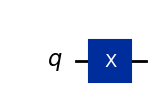

In [2]:
from IPython.display import display
qc_x = QuantumCircuit(1)
qc_x.x(0)
print("Quantum Circuit after applying X Gate")
display(qc_x.draw("mpl"))

In [3]:
state_x = Statevector.from_instruction(qc_x)
print("State Vector")
print(state_x)

State Vector
Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


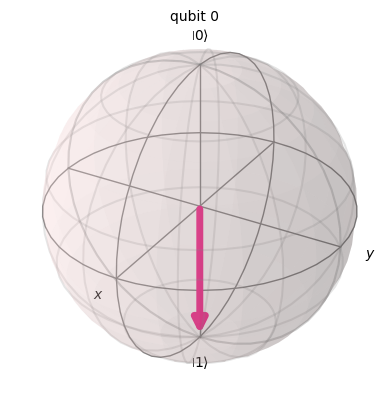

In [4]:
plot_bloch_multivector(state_x)

## Observation
The Pauli-X gate flips the qubit from the |0⟩ state to the |1⟩ state.
The Bloch Sphere shows the qubit moving from the north pole to the south pole,
indicating a complete bit flip.

### Pauli-Y Gate

The Pauli-Y gate performs a bit flip together with a phase change.

Matrix Representation

$$
Y=
\begin{bmatrix}
0&-i\\
i&0
\end{bmatrix}
$$

Quantum Circuit after applying Y Gate


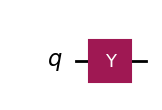

In [6]:
qc_y = QuantumCircuit(1)
qc_y.y(0)
print("Quantum Circuit after applying Y Gate")
display(qc_y.draw("mpl"))

In [7]:
state_y = Statevector.from_instruction(qc_y)
print("State Vector")
print(state_y)

State Vector
Statevector([0.+0.j, 0.+1.j],
            dims=(2,))


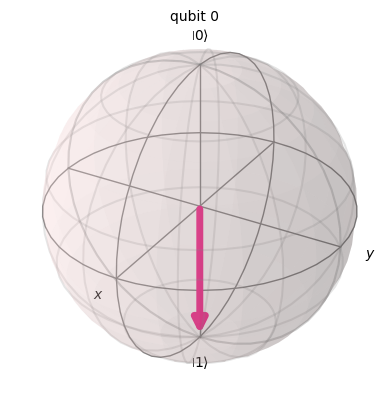

In [8]:
plot_bloch_multivector(state_y)

## Observation

The Pauli-Y gate changes both the state and the phase of the qubit.
Although the measurement probabilities remain unchanged, the phase difference
plays an important role in quantum computations.

### Pauli-Z Gate

The Pauli-Z gate changes the phase of the |1⟩ state without changing the
measurement probabilities.

To observe the phase change clearly, a Hadamard gate is applied first.

Matrix Representation

$$
Z=
\begin{bmatrix}
1&0\\
0&-1
\end{bmatrix}
$$

Quantum Circuit


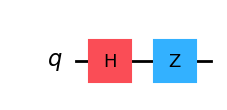

In [9]:
qc_z = QuantumCircuit(1)
qc_z.h(0)
qc_z.z(0)
print("Quantum Circuit")
display(qc_z.draw("mpl"))

In [10]:
state_z = Statevector.from_instruction(qc_z)
print("State Vector")
print(state_z)

State Vector
Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))


In [11]:
probabilities = np.abs(state_z.data)**2
print("Probability Distribution")
for state, prob in zip(["|0⟩","|1⟩"], probabilities):
    print(f"{state}: {prob:.2f}")

Probability Distribution
|0⟩: 0.50
|1⟩: 0.50


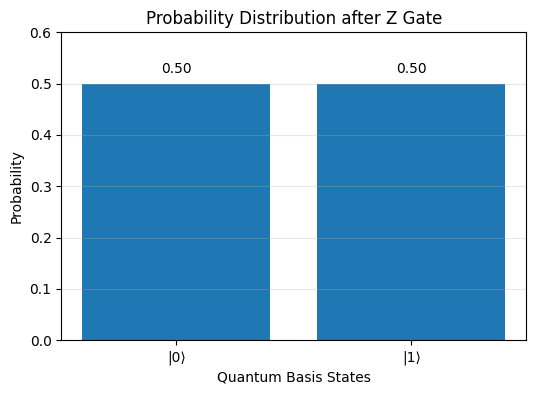

In [12]:
states=["|0⟩","|1⟩"]
plt.figure(figsize=(6,4))
bars=plt.bar(states,probabilities)
plt.title("Probability Distribution after Z Gate")
plt.xlabel("Quantum Basis States")
plt.ylabel("Probability")
plt.ylim(0,0.6)
plt.grid(axis="y",alpha=0.3)
for bar in bars:
    y=bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,
             y+0.02,
             f"{y:.2f}",
             ha='center')
plt.show()

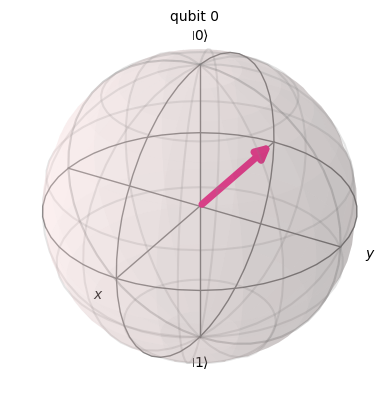

In [13]:
plot_bloch_multivector(state_z)

## Observation

The Pauli-Z gate changes only the phase of the quantum state.
The probability distribution remains unchanged, while the Bloch Sphere
illustrates the phase transformation introduced by the gate.